<a href="https://colab.research.google.com/github/Tanmay-Somani/100daysof-code/blob/main/Main_py.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [346]:
import os
import glob
import re
import logging
from datetime import datetime
import numpy as np
import cv2
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import random
from torchsummary import summary
from skimage.metrics import peak_signal_noise_ratio as psnr_metric, structural_similarity as ssim_metric
import time
import psutil
import gc

In [347]:
SEQ_LEN = 7
PRED_STEPS = 1
FULL_IMG_SIZE = 1500
IMG_SIZE = 512 # Temporarily reduced for debugging OOM error
BATCH_SIZE = 1
GRADIENT_ACCUMULATION_STEPS = 4
EPOCHS = 20
LR = 5e-4
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
SEED=42
DROPOUT_RATE = 0.3

TRAIN_SPLIT = 0.7
VAL_SPLIT = 0.15
TEST_SPLIT = 0.15 # Remaining for test (0.15)

In [348]:
BASE_DIR = "/content/project"

os.makedirs(BASE_DIR, exist_ok=True)

DATA_ROOT = f"{BASE_DIR}/data"
LOG_PATH = f"{BASE_DIR}/logs"
LOG_FILE=LOG_PATH+ "/train_cropped.log"
MODEL_PATH = f"{BASE_DIR}/models"
CHKPOINT_DIR = f"{MODEL_PATH}/checkpoints"
IMAGES_DIR = f"{BASE_DIR}/images" # New: Define images directory

for p in [DATA_ROOT, LOG_PATH, MODEL_PATH, CHKPOINT_DIR, IMAGES_DIR]: # New: Add IMAGES_DIR
    os.makedirs(p, exist_ok=True)

In [349]:
runno_file_path = LOG_PATH + '/runno.txt'

# Check if runno.txt exists, if not, create it and initialize with 0
if not os.path.exists(runno_file_path):
    with open(runno_file_path, 'w') as f:
        f.write('0')

# Now, read, increment, and write the run number
with open(runno_file_path, 'r') as R:
    runno = int(R.read())
with open(runno_file_path, 'w') as W:
    W.write(str(int(runno + 1)))

logging.basicConfig(level=logging.INFO, format="%(asctime)s | %(levelname)s | %(message)s",
                    handlers=[logging.FileHandler(LOG_FILE),
                              logging.StreamHandler()])

In [350]:

def set_seed(seed):
    """
    Sets the seeds for `random`, `numpy`, and `torch` libraries to ensure reproducibility.

    Args:
        seed (int): The seed value to be used.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

In [351]:
def parse_datetime(path):
    """
    Parses a datetime string from a file path.

    The file path is expected to be in the format "MMWYY_HHMM" or "MWWYY_HHMM", where:
        - MM: Month as a two-digit number (01-12)
        - W: Weekday (JAN-FEB etc.)
        - YY: Year as a four-digit number
        - HH: Hour in 24-hour format (00-23)
        - MM: Minute (00-59)

    Args:
        path (str): The file path to parse the datetime from.

    Returns:
        datetime: A datetime object representing the parsed date and time.

    Raises:
        ValueError: If the file path does not match the expected format.
    """
    name = os.path.basename(path)
    pattern = r"(\d{2})(\w{3})(\d{4})_(\d{4})"
    match = re.search(pattern, name)
    if not match:
        raise ValueError(f"Bad filename: {name}")
    month_map = {
        'JAN': '01','FEB': '02','MAR': '03','APR': '04','MAY': '05','JUN': '06',
        'JUL': '07','AUG': '08','SEP': '09','OCT': '10','NOV': '11','DEC': '12'
    }
    day=match.group(1)
    month = match.group(2)
    year=match.group(3)
    time=match.group(4)
    for key, value in month_map.items():
        if key in month:
            month = value
            break
    return datetime.strptime(f"{day}{month}{year}.{time}", "%d%m%Y.%H%M")


In [352]:
def mse(p,t):
    """
    Computes the mean squared error (MSE) between two tensors.

    Args:
        p (torch.tensor): The predicted tensor.
        t (torch.tensor): The target tensor.

    Returns:
        torch.tensor: The mean squared error value.
    """
    return torch.mean((p-t)**2)

def rmse(p,t):
    """
    Computes the root mean squared error (RMSE) between two tensors.

    Args:
        p (torch.tensor): The predicted tensor.
        t (torch.tensor): The target tensor.

    Returns:
        torch.tensor: The root mean squared error value.
    """
    return torch.sqrt(mse(p,t)+1e-8)

def mae(p,t):
    """
    Computes the mean absolute error (MAE) between two tensors.

    Args:
        p (torch.tensor): The predicted tensor.
        t (torch.tensor): The mean absolute error value.

    Returns:
        torch.tensor: The mean absolute error value.
    """
    return torch.mean(torch.abs(p-t))

def encode_time(dt):
    """
    Encodes a datetime object into sinusoidal representation.

    The encoding is based on the hour of the day, with values scaled to be between -1 and 1.

    Args:
        dt (datetime): The datetime object to encode.

    Returns:
        tuple: A pair of numpy arrays representing the sine and cosine components of the encoded time.
    """
    hour = dt.hour + dt.minute / 60.0
    sin = np.sin(2 * np.pi * hour / 24)
    cos = np.cos(2 * np.pi * hour / 24)
    return sin, cos

def gradient_loss(pred, target):
    """
    Computes the Gradient Difference Loss (GDL) between prediction and target.
    GDL penalizes differences in image gradients, encouraging sharper predictions.

    Args:
        pred (torch.Tensor): The predicted tensor (B, PRED_STEPS, C, H, W).
        target (torch.Tensor): The target tensor (B, PRED_STEPS, C, H, W).

    Returns:
        torch.Tensor: The GDL value.
    """
    # Calculate gradients along width (x-axis)
    grad_x_pred = torch.abs(pred[:, :, :, :, 1:] - pred[:, :, :, :, :-1])
    grad_x_target = torch.abs(target[:, :, :, :, 1:] - target[:, :, :, :, :-1])
    loss_x = torch.mean(torch.abs(grad_x_pred - grad_x_target))

    # Calculate gradients along height (y-axis)
    grad_y_pred = torch.abs(pred[:, :, :, 1:, :] - pred[:, :, :, :-1, :])
    grad_y_target = torch.abs(target[:, :, :, 1:, :] - target[:, :, :, :-1, :])
    loss_y = torch.mean(torch.abs(grad_y_pred - grad_y_target))

    return loss_x + loss_y

def sobel_filter_loss(pred, target):
    """
    Computes a loss based on the difference of Sobel filtered images.
    This encourages the model to capture edge information more accurately.

    Args:
        pred (torch.Tensor): Predicted tensor (B, PRED_STEPS, C, H, W).
        target (torch.Tensor): Target tensor (B, PRED_STEPS, C, H, W).

    Returns:
        torch.Tensor: The Sobel filter loss value.
    """
    # Define Sobel kernels
    sobel_x = torch.tensor([[-1., 0., 1.], [-2., 0., 2.], [-1., 0., 1.]], device=pred.device).view(1, 1, 3, 3)
    sobel_y = torch.tensor([[-1., -2., -1.], [0., 0., 0.], [1., 2., 1.]], device=pred.device).view(1, 1, 3, 3)

    # Reshape for convolution: (B * PRED_STEPS, C, H, W)
    # Assuming C=1 for grayscale images, so no change needed there if we're careful
    # Otherwise, you'd convolve over each channel or convert to grayscale for edge detection
    B, T, C, H, W = pred.shape
    pred_reshaped = pred.view(B * T, C, H, W)
    target_reshaped = target.view(B * T, C, H, W)

    # Apply Sobel filters
    grad_x_pred = nn.functional.conv2d(pred_reshaped, sobel_x, padding=1)
    grad_y_pred = nn.functional.conv2d(pred_reshaped, sobel_y, padding=1)
    grad_x_target = nn.functional.conv2d(target_reshaped, sobel_x, padding=1)
    grad_y_target = nn.functional.conv2d(target_reshaped, sobel_y, padding=1)

    # Calculate magnitude of gradients (L1 norm for simplicity, or L2 for smoother)
    pred_edges = torch.sqrt(grad_x_pred**2 + grad_y_pred**2)
    target_edges = torch.sqrt(grad_x_target**2 + grad_y_target**2)

    # Loss is the mean absolute difference between edge maps
    loss = torch.mean(torch.abs(pred_edges - target_edges))
    return loss

def loss_fn(pred, target):
    mse_val = mse(pred, target)
    mae_val = mae(pred, target)
    gdl_val = gradient_loss(pred, target)
    # Removed Sobel calculation
    ssim_val = calculate_ssim(pred, target) # Calculate SSIM

    # Updated total loss calculation with new weights
    total_loss = 0.45 * mse_val + 0.20 * mae_val + 0.30 * (1 - ssim_val) + 0.05 * gdl_val

    # Return values without sobel_val
    return total_loss, mse_val.item(), mae_val.item(), gdl_val.item(), ssim_val

def calculate_psnr(p, t):
    "Calculates PSNR between two tensors, handling batch, sequence, and channel dimensions."
    # Ensure tensors are on CPU and converted to numpy, then squeeze redundant dimensions
    p_np = p.detach().cpu().numpy().squeeze()
    t_np = t.detach().cpu().numpy().squeeze()

    if p_np.ndim == 2: # Single image (H, W)
        return psnr_metric(t_np, p_np, data_range=1.0)
    elif p_np.ndim == 3: # Batch of images (B, H, W)
        batch_psnr = [psnr_metric(t_np[i], p_np[i], data_range=1.0) for i in range(p_np.shape[0])]
        return np.mean(batch_psnr)
    else:
        raise ValueError(f"Unexpected number of dimensions for PSNR calculation: {p_np.ndim}")

def calculate_ssim(p, t):
    "Calculates SSIM between two tensors, handling batch, sequence, and channel dimensions."
    # Ensure tensors are on CPU and converted to numpy, then squeeze redundant dimensions
    p_np = p.detach().cpu().numpy().squeeze()
    t_np = t.detach().cpu().numpy().squeeze()

    if p_np.ndim == 2: # Single image (H, W)
        return ssim_metric(t_np, p_np, data_range=1.0)
    elif p_np.ndim == 3: # Batch of images (B, H, W)
        batch_ssim = [ssim_metric(t_np[i], p_np[i], data_range=1.0) for i in range(p_np.shape[0])]
        return np.mean(batch_ssim)
    else:
        raise ValueError(f"Unexpected number of dimensions for SSIM calculation: {p_np.ndim}")

In [353]:
def plot_metrics(hist):
    """Plots training, validation, and test metrics (Loss, PSNR, SSIM, MAE, MSE, RMSE, GDL) from the history dictionary."""

    metrics_to_plot = [
        ('loss', 'Loss', 'r'),
        ('psnr', 'PSNR', 'g'),
        ('ssim', 'SSIM', 'purple'),
        ('mae', 'Mean Absolute Error', 'orange'),
        ('mse', 'Mean Squared Error', 'brown'),
        ('rmse', 'Root Mean Squared Error', 'cyan'),
        ('gdl', 'Gradient Difference Loss', 'magenta')
    ]

    for metric_key, metric_name, test_color in metrics_to_plot:
        plt.figure(figsize=(10, 6))
        plt.plot(hist[f'train_{metric_key}'], label=f'Training {metric_name}')
        plt.plot(hist[f'val_{metric_key}'], label=f'Validation {metric_name}')

        # Check if test metric is available and plot it
        if f'test_{metric_key}' in hist and hist[f'test_{metric_key}']:
            if len(hist[f'test_{metric_key}']) == 1:
                plt.axhline(y=hist[f'test_{metric_key}'][0], color=test_color, linestyle='--', label=f'Test {metric_name}')
            else:
                plt.plot(hist[f'test_{metric_key}'], label=f'Test {metric_name}')

        plt.title(f'Training, Validation, and Test {metric_name} Over Epochs')
        plt.xlabel('Epoch')
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid(True)
        plt.show()


In [354]:
class SpatioTemporalDataset(Dataset):
    """
    Initializes the SpatioTemporalDataset class.

    Args:
        image_paths (list): A list of image file paths for the dataset.
        is_train (bool): Flag to indicate if the dataset is for training (enables augmentation).

    Note:
        This function takes pre-sorted image paths and creates a list of tuples containing input and target sequences.

    Attributes:
        samples (list[tuple]): A list of tuples, where each tuple contains an input sequence and a corresponding target sequence.
    """
    def __init__(self, image_paths, is_train=True):
        self.image_paths = image_paths
        self.samples = []
        self.is_train = is_train
        total_len = SEQ_LEN + PRED_STEPS

        for i in range(len(self.image_paths) - total_len):
            window = self.image_paths[i:i+total_len]
            inp = window[:SEQ_LEN]
            tgt = window[SEQ_LEN:]
            self.samples.append((inp, tgt))

        logging.info(f"Total valid samples for this split: {len(self.samples)}")

    def __len__(self):
        return len(self.samples)

    def load_img(self, path):
        """
        Load an image from a file.

        Args:
            path (str): The path to the image file.

        Returns:
            np.ndarray: The loaded image.
        """
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )
        img = img / 255.0
        return img

    def _add_gaussian_noise(self, image, mean=0., std=0.01):
        """
        Adds Gaussian noise to an image.
        """
        noise = np.random.normal(mean, std, image.shape)
        noisy_image = image + noise
        return np.clip(noisy_image, 0.0, 1.0)

    def _adjust_brightness(self, image, brightness_factor=0.1):
        """
        Adjusts the brightness of an image.
        """
        return np.clip(image + brightness_factor * (np.random.rand() * 2 - 1), 0.0, 1.0)

    def _augment_image(self, image, noise_std, brightness_factor):
        """
        Applies Gaussian noise and brightness shift to an image.
        """
        augmented_image = self._add_gaussian_noise(image, std=noise_std)
        augmented_image = self._adjust_brightness(augmented_image, brightness_factor=brightness_factor)
        return augmented_image

    def __getitem__(self, idx):
        seq = []
        targets = []
        inp_paths, tgt_paths = self.samples[idx]

        # Generate augmentation parameters once per sequence if in training mode
        noise_std = np.random.uniform(0.005, 0.02) if self.is_train else 0.0
        brightness_shift = np.random.uniform(-0.05, 0.05) if self.is_train else 0.0

        for p in inp_paths:
            img = self.load_img(p)
            if self.is_train:
                img = self._augment_image(img, noise_std, brightness_shift)

            dt = parse_datetime(p)
            sin, cos = encode_time(dt)
            time_map = np.ones_like(img)
            stacked = np.stack(
                [
                    img,
                    sin * time_map,
                    cos * time_map
                ],
                axis=0
            )
            seq.append(stacked)
        seq = np.stack(seq, axis=0)

        for p in tgt_paths:
            img = self.load_img(p)
            # Augment target frames with the same parameters as input frames
            if self.is_train:
                img = self._augment_image(img, noise_std, brightness_shift)
            targets.append(np.expand_dims(img, axis=0))
        targets = np.stack(targets, axis=0)
        return torch.tensor(seq, dtype=torch.float32), torch.tensor(targets, dtype=torch.float32)

In [355]:
class ConvLSTMCell(nn.Module):
    """
    A 2D Convolutional LSTM Cell.

    Attributes:
        hidden_dim (int): The number of output features in the cell.
        conv (nn.Conv2d): The convolutional layer that combines input and hidden state.

    Methods:
        forward(x, h, c): The forward pass through the cell.
    """
    def __init__(self, in_dim, hidden_dim):
        super().__init__()
        self.hidden_dim = hidden_dim
        self.conv = nn.Conv2d(
        in_dim + hidden_dim,
        4 * hidden_dim,
        3,
        padding=1
        )
        # Replaced BatchNorm2d with LayerNorm
        # LayerNorm needs to be applied after permuting dimensions to (B, H, W, C)
        self.ln = nn.LayerNorm(4 * hidden_dim)

    def forward(self, x, h, c):
        """
        The forward pass through the cell.

        Args:
            x (torch.Tensor): The input tensor.
            h (torch.Tensor): The current hidden state.
            c (torch.Tensor): The current cell state.

        Returns:
            tuple: A tuple containing the updated hidden and cell states.
        """

        combined = torch.cat([x, h], dim=1)
        out = self.conv(combined)

        # Apply LayerNorm: permute to (B, H, W, C), apply LN, then permute back
        out = out.permute(0, 2, 3, 1).contiguous() # (B, H, W, C)
        out = self.ln(out)
        out = out.permute(0, 3, 1, 2).contiguous() # (B, C, H, W)

        i, f, o, g = torch.chunk(out, 4, dim=1)
        i=torch.sigmoid(i)
        f=torch.sigmoid(f)
        o=torch.sigmoid(o)
        g=torch.tanh(g)
        c = f * c + i * g
        h = o * torch.tanh(c)
        return h, c

# =========================
# SPATIAL ATTENTION MODULE
# =========================
class SpatialAttention(nn.Module):
    """
    A lightweight spatial attention module.
    It processes the input feature map to generate spatial attention weights.
    """
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels, in_channels // 2, kernel_size=1)
        self.relu = nn.ReLU()
        self.conv2 = nn.Conv2d(in_channels // 2, 1, kernel_size=1)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        """
        Forward pass for the spatial attention module.
        Args:
            x (torch.Tensor): Input feature map (B, C, H, W).
        Returns:
            torch.Tensor: Attention-weighted feature map (B, C, H, W).
        """
        attn_weights = self.conv1(x)
        attn_weights = self.relu(attn_weights)
        attn_weights = self.conv2(attn_weights)
        attn_weights = self.sigmoid(attn_weights) # Output (B, 1, H, W)
        return x * attn_weights # Apply attention as a multiplicative mask

# =========================
# SQUEEZE-AND-EXCITATION BLOCK (Channel Attention)
# =========================
class SEBlock(nn.Module):
    """
    A Squeeze-and-Excitation (SE) block for channel-wise attention.
    It adaptively recalibrates channel-wise feature responses.
    """
    def __init__(self, channel, reduction=16):
        super().__init__()
        self.avg_pool = nn.AdaptiveAvgPool2d(1) # Global average pooling
        self.fc = nn.Sequential(
            nn.Linear(channel, channel // reduction, bias=False),
            nn.ReLU(inplace=True),
            nn.Linear(channel // reduction, channel, bias=False),
            nn.Sigmoid() # Scale values between 0 and 1
        )

    def forward(self, x):
        b, c, _, _ = x.size()
        y = self.avg_pool(x).view(b, c) # Squeeze operation
        y = self.fc(y).view(b, c, 1, 1) # Excitation operation and reshape
        return x * y.expand_as(x)


# =========================
# MODEL (Encoder-Decoder ConvLSTM with new architecture)
# =========================
class ConvLSTMModel(nn.Module):
    def __init__(self, dropout_rate=0.3):
        super().__init__()
        self.relu = nn.ReLU()

        # Encoder path
        # Level 1 (Full Res)
        self.conv_in = nn.Conv2d(3, 32, kernel_size=3, padding=1) # Input (C=3) to 32 channels
        # Level 2 (Half Res)
        self.pool1 = nn.MaxPool2d(2, 2) # Downsample H, W by 2
        self.conv_mid = nn.Conv2d(32, 64, kernel_size=3, padding=1) # 32 channels to 64 channels
        # Level 3 (Quarter Res) - input to ConvLSTM
        self.pool2 = nn.MaxPool2d(2, 2) # Downsample H, W by 2 again
        self.conv_deep = nn.Conv2d(64, 128, kernel_size=3, padding=1) # 64 channels to 128 channels

        # Encoder ConvLSTM part (takes 128 channels from conv_deep)
        self.encoder_convlstm_hidden_dims = [128, 128] # Two layers with 128 hidden_dim each
        self.encoder_convlstm_cells = nn.ModuleList()
        self.encoder_convlstm_cells.append(ConvLSTMCell(128, self.encoder_convlstm_hidden_dims[0]))
        for i in range(1, len(self.encoder_convlstm_hidden_dims)):
            self.encoder_convlstm_cells.append(ConvLSTMCell(self.encoder_convlstm_hidden_dims[i-1], self.encoder_convlstm_hidden_dims[i]))

        # Decoder ConvLSTM part
        self.decoder_convlstm_hidden_dims = [128, 128] # Two layers with 128 hidden_dim each
        self.decoder_convlstm_cells = nn.ModuleList()
        self.decoder_convlstm_cells.append(ConvLSTMCell(self.encoder_convlstm_hidden_dims[-1], self.decoder_convlstm_hidden_dims[0]))
        for i in range(1, len(self.decoder_convlstm_hidden_dims)):
            self.decoder_convlstm_cells.append(ConvLSTMCell(self.decoder_convlstm_hidden_dims[i-1], self.decoder_convlstm_hidden_dims[i]))

        # Modules applied *after* the decoder ConvLSTM for each prediction step
        self.se_block = SEBlock(channel=self.decoder_convlstm_hidden_dims[-1]) # applied to decoder_h (128 channels)
        self.spatial_attention = SpatialAttention(self.decoder_convlstm_hidden_dims[-1]) # applied after SE (128 channels)

        # Decoder path (upsampling with skip connections)
        # Level 2 Upsample
        self.upconv2 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2) # Upsample H/4,W/4 to H/2,W/2
        self.dec_conv2 = nn.Conv2d(64 + 64, 64, kernel_size=3, padding=1) # Combine with skip connection from conv_mid

        # Level 1 Upsample
        self.upconv1 = nn.ConvTranspose2d(64, 32, kernel_size=2, stride=2) # Upsample H/2,W/2 to H,W
        self.dec_conv1 = nn.Conv2d(32 + 32, 32, kernel_size=3, padding=1) # Combine with skip connection from conv_in

        # Final output convolution (from previous change)
        self.final_output_conv = nn.Sequential(
            nn.Conv2d(32, 32, kernel_size=3, padding=1), # Intermediate 3x3 conv
            nn.ReLU(),
            nn.Conv2d(32, 1, kernel_size=1) # Final 1x1 conv
        )

        self.dropout = nn.Dropout2d(p=dropout_rate)

    def forward(self, x):
        B, T_enc, C, H, W = x.shape

        last_input_frame = x[:, T_enc - 1, 0, :, :].unsqueeze(1) # Shape (B, 1, H, W)

        encoder_outputs_level1 = [] # For skip connection (B, 32, H, W)
        encoder_outputs_level2 = [] # For skip connection (B, 64, H/2, W/2)
        processed_frames_for_convlstm = [] # For ConvLSTM (B, 128, H/4, W/4)

        for t in range(T_enc):
            frame = x[:, t] # (B, C=3, H, W)

            # Level 1 (Full Res)
            conv_in_output = self.relu(self.conv_in(frame)) # (B, 32, H, W)
            encoder_outputs_level1.append(conv_in_output)

            # Level 2 (Half Res)
            pooled1_output = self.pool1(conv_in_output) # (B, 32, H/2, W/2)
            conv_mid_output = self.relu(self.conv_mid(pooled1_output)) # (B, 64, H/2, W/2)
            encoder_outputs_level2.append(conv_mid_output)

            # Level 3 (Quarter Res)
            pooled2_output = self.pool2(conv_mid_output) # (B, 64, H/4, W/4)
            conv_deep_output = self.relu(self.conv_deep(pooled2_output)) # (B, 128, H/4, W/4)
            processed_frames_for_convlstm.append(conv_deep_output)

        # Initialize Encoder ConvLSTM hidden and cell states
        encoder_h_c_states = []
        H_convlstm, W_convlstm = H // 4, W // 4 # Dimensions after two downsamplings
        for hidden_dim in self.encoder_convlstm_hidden_dims:
            encoder_h_c_states.append((
                torch.zeros(B, hidden_dim, H_convlstm, W_convlstm, device=x.device),
                torch.zeros(B, hidden_dim, H_convlstm, W_convlstm, device=x.device)
            ))

        # Run Encoder ConvLSTM
        for t in range(T_enc):
            current_layer_input = processed_frames_for_convlstm[t] # (B, 128, H/4, W/4)
            for i, cell in enumerate(self.encoder_convlstm_cells):
                h, c = cell(current_layer_input, encoder_h_c_states[i][0], encoder_h_c_states[i][1])
                if self.training:
                    h = self.dropout(h)
                encoder_h_c_states[i] = (h, c)
                current_layer_input = h # Output of current layer becomes input for next layer

        # Decoder pass: Use final encoder states to initialize decoder ConvLSTM
        decoder_h_c_states = list(encoder_h_c_states) # Initialize decoder states with final encoder states

        outputs = []
        decoder_input_for_first_layer = decoder_h_c_states[-1][0] # (B, 128, H/4, W/4)

        # Get skip connection sources from the *last* encoder input frame
        skip_feature_level1 = encoder_outputs_level1[-1] # (B, 32, H, W)
        skip_feature_level2 = encoder_outputs_level2[-1] # (B, 64, H/2, W/2)

        for t_pred in range(PRED_STEPS):
            current_layer_input = decoder_input_for_first_layer

            for i, cell in enumerate(self.decoder_convlstm_cells):
                h, c = cell(current_layer_input, decoder_h_c_states[i][0], decoder_h_c_states[i][1])
                if self.training:
                    h = self.dropout(h)
                decoder_h_c_states[i] = (h, c)
                current_layer_input = h # Output of current layer becomes input for next layer

            # After decoder ConvLSTM, apply post-processing modules for each predicted frame
            decoder_final_h = decoder_h_c_states[-1][0] # (B, 128, H/4, W/4)

            se_refined_h = self.se_block(decoder_final_h) # (B, 128, H/4, W/4)
            attended_h = self.spatial_attention(se_refined_h) # (B, 128, H/4, W/4)

            # Level 2 Upsample with skip connection
            upsampled_h2 = self.upconv2(attended_h) # (B, 64, H/2, W/2)
            combined_features_level2 = torch.cat([upsampled_h2, skip_feature_level2], dim=1) # (B, 64+64, H/2, W/2)
            processed_features_level2 = self.relu(self.dec_conv2(combined_features_level2)) # (B, 64, H/2, W/2)

            # Level 1 Upsample with skip connection
            upsampled_h1 = self.upconv1(processed_features_level2) # (B, 32, H, W)
            combined_features_level1 = torch.cat([upsampled_h1, skip_feature_level1], dim=1) # (B, 32+32, H, W)
            processed_features_level1 = self.relu(self.dec_conv1(combined_features_level1)) # (B, 32, H, W)

            # Residual prediction
            predicted_change = self.final_output_conv(processed_features_level1)
            predicted_frame = torch.clamp(last_input_frame + predicted_change, 0, 1) # (B, 1, H, W)
            outputs.append(predicted_frame)

        return torch.stack(outputs, dim=1) # (B, PRED_STEPS, 1, H, W)


In [356]:
model = ConvLSTMModel(dropout_rate=DROPOUT_RATE).to(DEVICE)

### Model Summary (with current IMG_SIZE)

In [357]:
# Ensure the model is in evaluation mode for summary generation
model.eval()

# BATCH_SIZE, SEQ_LEN, C, H, W
dummy_input_size = (BATCH_SIZE, SEQ_LEN, 3, IMG_SIZE, IMG_SIZE)
print(f"Generating model summary with input size: {dummy_input_size}")

try:
    summary(model, input_size=(SEQ_LEN, 3, IMG_SIZE, IMG_SIZE))
except RuntimeError as e:
    print(f"Error generating summary: {e}. This might happen if the input size is too large for GPU memory.")


Generating model summary with input size: (1, 7, 3, 512, 512)
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 512, 512]             896
              ReLU-2         [-1, 32, 512, 512]               0
         MaxPool2d-3         [-1, 32, 256, 256]               0
            Conv2d-4         [-1, 64, 256, 256]          18,496
              ReLU-5         [-1, 64, 256, 256]               0
         MaxPool2d-6         [-1, 64, 128, 128]               0
            Conv2d-7        [-1, 128, 128, 128]          73,856
              ReLU-8        [-1, 128, 128, 128]               0
            Conv2d-9         [-1, 32, 512, 512]             896
             ReLU-10         [-1, 32, 512, 512]               0
        MaxPool2d-11         [-1, 32, 256, 256]               0
           Conv2d-12         [-1, 64, 256, 256]          18,496
             ReLU-13         [-1, 64, 256

In [358]:
pip install visualtorch

In [359]:
import visualtorch

# Ensure the model is in evaluation mode
model.eval()

# Assuming dummy_input is already defined and moved to the correct device
# from previous cells for torchviz or torchsummary
# If not, it would need to be created here:
# dummy_input = torch.randn(BATCH_SIZE, SEQ_LEN, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

# Visualtorch expects a single input tensor for the forward pass, so we'll use the first timestep
# or adjust the model's forward to handle the SEQ_LEN dimension if it's meant to process that way.
# For a high-level view, we can often pass a single sample (batch=1, sequence=1, etc.)
# Given the model expects (B, T_enc, C, H, W), let's reshape for visualtorch if it expects a single tensor
# Or, more directly, visualize by feeding a single sequence at a time if the tool allows

# For simplicity and given the model's forward expects (B, T_enc, C, H, W):
# visualtorch usually works best with a direct input to the first layer.
# Let's try to pass the dummy_input directly.

# visualtorch.vis_model(model, dummy_input)

ConvLSTMModel(
  (relu): ReLU()
  (conv_in): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_mid): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv_deep): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (encoder_convlstm_cells): ModuleList(
    (0-1): 2 x ConvLSTMCell(
      (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (ln): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
  )
  (decoder_convlstm_cells): ModuleList(
    (0-1): 2 x ConvLSTMCell(
      (conv): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (ln): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
    )
  )
  (se_block): SEBlock(
    (avg_pool): AdaptiveAvgPool2d(output_size=1)
    (fc): Sequential(
      (0

In [360]:
pip install torchview

In [361]:
from torchview import draw_graph

# Ensure the model is in evaluation mode
model.eval()

# Generate a dummy input matching the model's expected input shape
# (BATCH_SIZE, SEQ_LEN, C, H, W)
dummy_input_for_graph = torch.randn(BATCH_SIZE, SEQ_LEN, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)

# Draw the model graph
model_graph = draw_graph(model, input_size=(BATCH_SIZE, SEQ_LEN, 3, IMG_SIZE, IMG_SIZE), device=DEVICE, save_graph=True, filename='convlstm_model_torchview', depth=5)

print("Model graph saved as convlstm_model_torchview.png. Displaying below:")

from IPython.display import Image
Image('convlstm_model_torchview.png')

Model graph saved as convlstm_model_torchview.png. Displaying below:


### Missing Prediction Saving

The `save_predictions` function is defined, but it is currently not being called anywhere in the training, validation, or testing loops. If you want to visualize the actual predicted images during or after training, you would need to add calls to this function. For example, you could add it within `test_model` to save predictions from the test set.

In [362]:
def save_predictions(predicted_frames_tensor, target_frames_tensor, epoch, split_name="", sample_idx=0, num_samples=1):
    """
    Saves predicted and target frames as images to a specified directory.

    Args:
        predicted_frames_tensor (torch.Tensor): The predicted frames tensor (B, PRED_STEPS, C, H, W).
        target_frames_tensor (torch.Tensor): The target frames tensor (B, PRED_STEPS, C, H, W).
        epoch (int): The current epoch number.
        split_name (str): The name of the data split (e.g., 'train', 'val', 'test').
        sample_idx (int): The index of the sample within the batch to save.
        num_samples (int): How many samples from the batch to save.
    """
    # Ensure IMAGES_DIR exists
    if not os.path.exists(IMAGES_DIR):
        os.makedirs(IMAGES_DIR)

    # Convert tensors to numpy arrays and un-normalize (scale to 0-255)
    predicted_np = (predicted_frames_tensor[sample_idx].detach().cpu().numpy() * 255).astype(np.uint8)
    target_np = (target_frames_tensor[sample_idx].detach().cpu().numpy() * 255).astype(np.uint8)

    for i in range(min(num_samples, predicted_np.shape[0])):
        pred_img = predicted_np[i].squeeze() # Remove channel dimension if C=1
        target_img = target_np[i].squeeze()

        # Create a directory for this epoch's predictions if it doesn't exist
        epoch_dir = os.path.join(IMAGES_DIR, f"epoch_{epoch}")
        if not os.path.exists(epoch_dir):
            os.makedirs(epoch_dir)

        # Save predicted frame
        pred_filename = os.path.join(epoch_dir, f"{split_name}_pred_e{epoch}_s{sample_idx}_p{i}.png")
        cv2.imwrite(pred_filename, pred_img)

        # Save target frame
        target_filename = os.path.join(epoch_dir, f"{split_name}_target_e{epoch}_s{sample_idx}_t{i}.png")
        cv2.imwrite(target_filename, target_img)

    logging.debug(f"Saved {num_samples} prediction(s) and target(s) for epoch {epoch}, split {split_name} to {epoch_dir}/")

In [363]:
def get_resource_usage(stage_name):
    process = psutil.Process(os.getpid())
    mem_info = process.memory_info()
    cpu_percent = process.cpu_percent(interval=None) # Non-blocking call
    logging.info(f"[{stage_name} Resource Usage] CPU: {cpu_percent:.2f}% | RAM: {mem_info.rss / (1024 ** 2):.2f} MB")
    if DEVICE == 'cuda':
        try:
            logging.info(f"[{stage_name} Resource Usage] GPU Memory Allocated: {torch.cuda.memory_allocated() / (1024 ** 2):.2f} MB | GPU Memory Cached: {torch.cuda.memory_reserved() / (1024 ** 2):.2f} MB")
        except RuntimeError as e:
            logging.warning(f"Could not get GPU memory usage: {e}")

def train_epoch(model, train_loader, opt, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim, scheduler):
    start_time_epoch = time.time()
    model.train()
    train_totals = {k: 0 for k in ["loss", "mae", "mse", "rmse", "psnr", "ssim", "gdl"]}
    train_cnt = 0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1} [Train]")

    opt.zero_grad() # Zero gradients at the beginning of the epoch

    for batch_idx, (x, y) in enumerate(pbar):
        start_time_batch = time.time()
        x, y = x.to(DEVICE), y.to(DEVICE)

        pred = model(x)
        # Updated unpacking for loss_fn return values (removed sobel_val)
        total_loss, mse_val, mae_val, gdl_val, ssim_val = loss_fn(pred, y)
        total_loss = total_loss / GRADIENT_ACCUMULATION_STEPS # Scale the loss for gradient accumulation

        total_loss.backward() # Perform backward pass

        if (batch_idx + 1) % GRADIENT_ACCUMULATION_STEPS == 0 or (batch_idx + 1) == len(train_loader): # Perform optimization step
            opt.step() # Update optimizer
            opt.zero_grad() # Zero gradients after optimization step

        with torch.no_grad():
            train_totals["loss"] += (total_loss * GRADIENT_ACCUMULATION_STEPS).item() # Unscale loss for logging
            train_totals["mae"] += mae_val
            train_totals["mse"] += mse_val
            train_totals["rmse"] += rmse(pred, y).item()
            train_totals["psnr"] += calculate_psnr(pred, y)
            train_totals["ssim"] += ssim_val # Added SSIM value
            train_totals["gdl"] += gdl_val
            # Removed sobel_val
            train_cnt += 1

        pbar.set_postfix(loss=(total_loss * GRADIENT_ACCUMULATION_STEPS).item()) # Display unscaled loss
        end_time_batch = time.time()
        logging.debug(f"Epoch {epoch+1} [Train] Batch Time: {end_time_batch - start_time_batch:.4f}s")
        get_resource_usage(f"Epoch {epoch+1} [Train] Batch")

    for k in train_totals: hist[f"train_{k}"].append(train_totals[k] / train_cnt if train_cnt > 0 else 0)
    scheduler.step() # Update learning rate at the end of the epoch
    end_time_epoch = time.time()
    logging.info(f"Epoch {epoch+1} [Train] Avg Loss: {hist['train_loss'][-1]:.4f}, MAE: {hist['train_mae'][-1]:.4f}, PSNR: {hist['train_psnr'][-1]:.4f}, SSIM: {hist['train_ssim'][-1]:.4f}, GDL: {hist['train_gdl'][-1]:.4f}) | Duration: {end_time_epoch - start_time_epoch:.4f}s")
    get_resource_usage(f"Epoch {epoch+1} [Train] End")

def validate_epoch(model, val_loader, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim):
    start_time_epoch = time.time()
    model.eval()
    val_totals = {k: 0 for k in ["loss", "mae", "mse", "rmse", "psnr", "ssim", "gdl"]}
    val_cnt = 0
    pbar_val = tqdm(val_loader, desc=f"Epoch {epoch+1} [Val]")

    with torch.no_grad():
        for x, y in pbar_val:
            start_time_batch = time.time()
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            # Updated unpacking for loss_fn return values (removed sobel_val)
            total_loss, mse_val, mae_val, gdl_val, ssim_val = loss_fn(pred, y)

            val_totals["loss"] += total_loss.item()
            val_totals["mae"] += mae_val
            val_totals["mse"] += mse_val
            val_totals["rmse"] += rmse(pred, y).item()
            val_totals["psnr"] += calculate_psnr(pred, y)
            val_totals["ssim"] += ssim_val # Added SSIM value
            val_totals["gdl"] += gdl_val
            # Removed sobel_val
            val_cnt += 1

            pbar_val.set_postfix(loss=total_loss.item())
            end_time_batch = time.time()
            logging.debug(f"Epoch {epoch+1} [Val] Batch Time: {end_time_batch - start_time_batch:.4f}s")
            get_resource_usage(f"Epoch {epoch+1} [Val] Batch")

    for k in val_totals: hist[f"val_{k}"].append(val_totals[k] / val_cnt if val_cnt > 0 else 0)
    end_time_epoch = time.time()
    logging.info(f"Epoch {epoch+1} [Val] Avg Loss: {hist['val_loss'][-1]:.4f}, MAE: {hist['val_mae'][-1]:.4f}, PSNR: {hist['val_psnr'][-1]:.4f}, SSIM: {hist['val_ssim'][-1]:.4f}, GDL: {hist['val_gdl'][-1]:.4f}) | Duration: {end_time_epoch - start_time_epoch:.4f}s")
    get_resource_usage(f"Epoch {epoch+1} [Val] End")
    return hist['val_loss'][-1]

def test_model(model, test_loader, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim):
    start_time_test = time.time()
    model.eval()
    test_totals = {k: 0 for k in ["loss", "mae", "mse", "rmse", "psnr", "ssim", "gdl"]}
    test_cnt = 0
    pbar_test = tqdm(test_loader, desc="[Test]")

    checkpoint_epoch = -1 # Default to -1 if no checkpoint is loaded
    if os.path.exists(os.path.join(CHKPOINT_DIR, "best_model.pth")):
        state_dict = torch.load(os.path.join(CHKPOINT_DIR, "best_model.pth"))
        if isinstance(state_dict, dict) and 'model' in state_dict:
            model.load_state_dict(state_dict['model'])
            checkpoint_epoch = state_dict.get("epoch", -1)
        else:
            model.load_state_dict(state_dict)
        logging.info(f"Loaded best model from epoch {checkpoint_epoch} for testing.")

    with torch.no_grad():
        for x, y in pbar_test:
            start_time_batch = time.time()
            x, y = x.to(DEVICE), y.to(DEVICE)
            pred = model(x)
            # Updated unpacking for loss_fn return values (removed sobel_val)
            total_loss, mse_val, mae_val, gdl_val, ssim_val = loss_fn(pred, y)

            test_totals["loss"] += total_loss.item()
            test_totals["mae"] += mae_val
            test_totals["mse"] += mse_val
            test_totals["rmse"] += rmse(pred, y).item()
            test_totals["psnr"] += calculate_psnr(pred, y)
            test_totals["ssim"] += ssim_val # Added SSIM value
            test_totals["gdl"] += gdl_val
            # Removed sobel_val
            test_cnt += 1

            # Call save_predictions here for the test set
            save_predictions(pred, y, checkpoint_epoch, split_name="test")

            pbar_test.set_postfix(loss=total_loss.item())
            end_time_batch = time.time()
            logging.debug(f"[Test] Batch Time: {end_time_batch - start_time_batch:.4f}s")
            get_resource_usage("[Test] Batch")

    for k in test_totals: hist[f"test_{k}"].append(test_totals[k] / test_cnt if test_cnt > 0 else 0)
    end_time_test = time.time()
    logging.info(f"[Test] Avg Loss: {hist['test_loss'][-1]:.4f}, MAE: {hist['test_mae'][-1]:.4f}, PSNR: {hist['test_psnr'][-1]:.4f}, SSIM: {hist['test_ssim'][-1]:.4f}, GDL: {hist['test_gdl'][-1]:.4f}) | Duration: {end_time_test - start_time_test:.4f}s")
    get_resource_usage("[Test] End")

In [364]:
def run_experiment(max_images=None):
    start_time_experiment = time.time()
    logging.info("Loading and preparing data...")
    get_resource_usage("Data Loading Start")

    # Add this line to ensure save_predictions is available if defined globally
    from __main__ import save_predictions
    from __main__ import found_images # Import found_images from the global scope

    # Use the 'found_images' list that was confirmed to contain files
    all_image_paths = sorted(found_images)

    if max_images is not None:
        all_image_paths = all_image_paths[:max_images]

    # Debug print to confirm the number of images seen by run_experiment
    print(f"run_experiment sees {len(all_image_paths)} images before train_test_split.")

    if len(all_image_paths) == 0:
        raise ValueError("No image files found. Cannot proceed with experiment.")

    # Split data into train, validation, and test sets
    train_paths, test_paths = train_test_split(all_image_paths, test_size=TEST_SPLIT, random_state=SEED)
    train_paths, val_paths = train_test_split(train_paths, test_size=VAL_SPLIT/(TRAIN_SPLIT+VAL_SPLIT), random_state=SEED)

    logging.info(f"Total images: {len(all_image_paths)}")
    logging.info(f"Train images: {len(train_paths)}")
    logging.info(f"Validation images: {len(val_paths)}")
    logging.info(f"Test images: {len(test_paths)}")

    # Create datasets and dataloaders
    train_dataset = SpatioTemporalDataset(train_paths, is_train=True)
    val_dataset = SpatioTemporalDataset(val_paths, is_train=False)
    test_dataset = SpatioTemporalDataset(test_paths, is_train=False)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
    get_resource_usage("Data Loading End")

    logging.info("Initializing model, optimizer, and history...")
    get_resource_usage("Model Init Start")
    model = ConvLSTMModel(dropout_rate=DROPOUT_RATE).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=LR)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=EPOCHS)
    hist = {k: [] for k in [
        "train_loss", "train_mae", "train_mse", "train_rmse", "train_psnr", "train_ssim", "train_gdl",
        "val_loss", "val_mae", "val_mse", "val_rmse", "val_psnr", "val_ssim", "val_gdl",
        "test_loss", "test_mae", "test_mse", "test_rmse", "test_psnr", "test_ssim", "test_gdl"
    ]}

    best_val_loss = float('inf')
    patience = 5
    epochs_no_improve = 0
    get_resource_usage("Model Init End")

    logging.info("Starting training process...")
    get_resource_usage("Training Start")
    for epoch in range(EPOCHS):
        train_epoch(model, train_loader, opt, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim, scheduler)
        val_loss = validate_epoch(model, val_loader, epoch, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            epochs_no_improve = 0
            torch.save({"model": model.state_dict(), "opt": opt.state_dict(), "epoch": epoch}, os.path.join(CHKPOINT_DIR, "best_model.pth"))
            logging.info(f"Validation loss improved. Best model saved at epoch {epoch+1}.")
        else:
            epochs_no_improve += 1
            logging.info(f"Validation loss did not improve. Patience: {epochs_no_improve}/{patience}")

        torch.save({"model": model.state_dict(), "opt": opt.state_dict(), "epoch": epoch}, os.path.join(CHKPOINT_DIR, f"epoch_{epoch}.pth"))
        logging.info(f"Checkpoint saved: epoch_{epoch}.pth")

        if epochs_no_improve == patience:
            logging.info(f"Early stopping triggered after {patience} epochs without improvement.")
            break
    get_resource_usage("Training End")

    logging.info("Training complete. Running final evaluation on test set...")
    test_model(model, test_loader, hist, DEVICE, loss_fn, mae, mse, rmse, calculate_psnr, calculate_ssim)
    logging.info("Project finished.")

    end_time_experiment = time.time()
    logging.info(f"Total Experiment Duration: {end_time_experiment - start_time_experiment:.4f}s")
    get_resource_usage("Experiment End")
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

    return hist, train_paths, val_paths, test_paths

### Inference Function

This `inference` function allows you to use the trained `ConvLSTMModel` to predict future frames given a sequence of historical frames. It mimics the data preprocessing steps of the `SpatioTemporalDataset` to prepare the input for the model.

In [365]:
def inference(model, input_image_paths, device):
    """
    Performs inference using the trained ConvLSTM model on a sequence of input images.

    Args:
        model (nn.Module): The trained ConvLSTM model.
        input_image_paths (list): A list of file paths for the input image sequence.
        device (str): The device ('cuda' or 'cpu') to run inference on.

    Returns:
        torch.Tensor: The predicted future image(s).
    """
    start_time_inference = time.time()
    get_resource_usage("Inference Start")

    model.eval()
    seq = []

    def load_and_preprocess_img(path):
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(
            img,
            (IMG_SIZE, IMG_SIZE),
            interpolation=cv2.INTER_AREA
        )
        img = img / 255.0
        return img

    for p in input_image_paths:
        img = load_and_preprocess_img(p)
        dt = parse_datetime(p) # Using the existing parse_datetime utility
        sin, cos = encode_time(dt) # Using the existing encode_time utility
        time_map = np.ones_like(img)
        stacked = np.stack(
            [
                img,
                sin * time_map,
                cos * time_map
            ],
            axis=0
        )
        seq.append(stacked)

    seq = np.stack(seq, axis=0)
    # Add batch dimension: (1, SEQ_LEN, C, H, W)
    input_tensor = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)

    with torch.no_grad():
        predictions = model(input_tensor)

    # The model outputs (B, PRED_STEPS, C=1, H, W). Squeeze if PRED_STEPS=1 and C=1 for easier handling.
    predicted_frames = predictions.detach().cpu().numpy().squeeze()

    end_time_inference = time.time()
    logging.info(f"Inference Duration: {end_time_inference - start_time_inference:.4f}s")
    get_resource_usage("Inference End")
    gc.collect()
    if DEVICE == 'cuda':
        torch.cuda.empty_cache()

    return predicted_frames

In [366]:
if __name__ == "__main__":
    logging.info('----------------------------------------------------------------')
    logging.info("Starting Project...")
    logging.info(f"Run No. {runno}")
    logging.info("Configurations: ")
    logging.info("Sequence length of images taken "+ str(SEQ_LEN))
    logging.info("Current Batch Size taken " + str(BATCH_SIZE))
    logging.info("Number of Epochs in the run "+str(EPOCHS))
    logging.info("Current training image resolution " + str(IMG_SIZE))
    logging.info("Learning Rate "+str(LR))
    logging.info(f"DEVICE {DEVICE}")
    set_seed(SEED)

    # Explicitly define split constants here to ensure they are available
    # if the previous configuration cell was not executed or updated.
    TRAIN_SPLIT = 0.7
    VAL_SPLIT = 0.15
    TEST_SPLIT = 0.15
    DEBUG_MAX_IMAGES = 60 # Increased from 60 to ensure enough images for all splits

    try:
        global hist, train_paths, val_paths, test_paths # Declare as global
        hist, train_paths, val_paths, test_paths = run_experiment(max_images=DEBUG_MAX_IMAGES) # Capture all returned values
    except Exception as e:
        logging.exception(f"Fatal error: {e}")

run_experiment sees 60 images before train_test_split.


[Test]: 100%|██████████| 1/1 [00:00<00:00,  1.26it/s, loss=0.143]


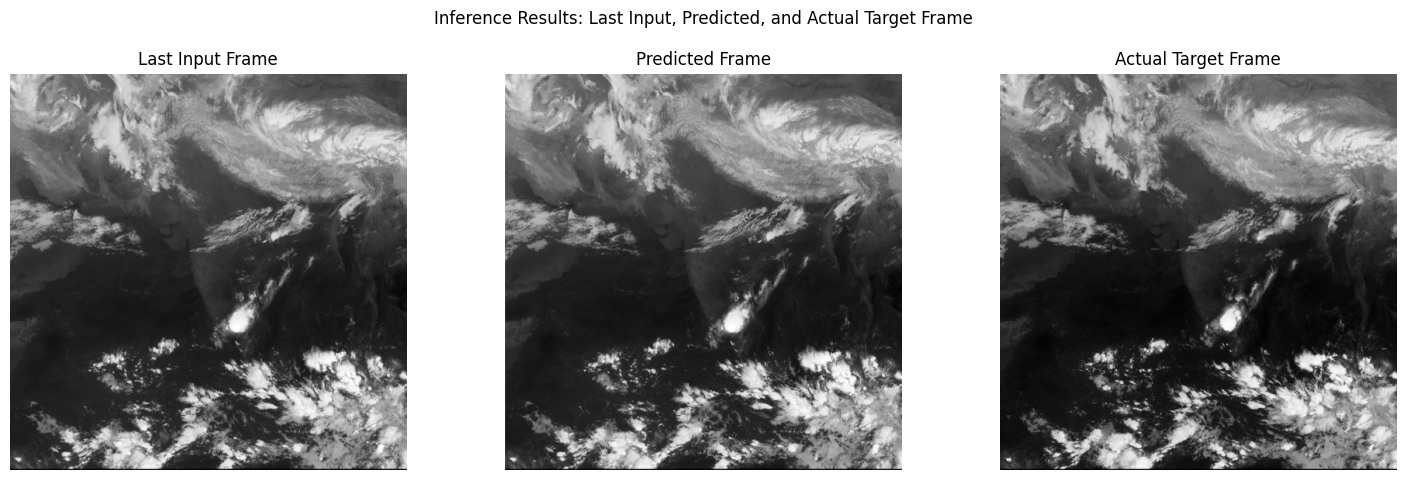

In [367]:
logging.info("\n--- Demonstrating Inference ---")

# Load the best model
inference_model = ConvLSTMModel().to(DEVICE)
best_model_path = os.path.join(CHKPOINT_DIR, "best_model.pth")
if os.path.exists(best_model_path):
    # Load the entire checkpoint dictionary
    checkpoint = torch.load(best_model_path)
    # Extract the model's state_dict from the checkpoint
    # Use strict=False to handle architectural mismatches if the model definition changed after saving.
    inference_model.load_state_dict(checkpoint["model"], strict=False)
    logging.warning("Model loaded with strict=False due to potential architectural changes. "
                    "Missing or mismatched keys were ignored. For full compatibility, consider "
                    "re-training the model with the current architecture if this is not intended.")
    logging.info("Loaded best model for inference.")
else:
    logging.warning("Best model not found. Training might not have completed or saved a best model.")

# Get a sample input sequence from the test set
# This assumes `test_paths` was populated by `run_experiment`
if 'test_paths' in globals() and len(test_paths) >= SEQ_LEN + PRED_STEPS:
    sample_input_paths = test_paths[0:SEQ_LEN]
    actual_target_path = test_paths[SEQ_LEN]

    logging.info(f"Sample Input Paths for Inference: {sample_input_paths}")
    logging.info(f"Actual Target Path for Comparison: {actual_target_path}")

    predicted_frames = inference(inference_model, sample_input_paths, DEVICE)

    # Display the last input frame, the predicted frame, and the actual target frame
    last_input_img = cv2.resize(cv2.imread(sample_input_paths[-1], cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA) / 255.0
    actual_target_img = cv2.resize(cv2.imread(actual_target_path, cv2.IMREAD_GRAYSCALE), (IMG_SIZE, IMG_SIZE), interpolation=cv2.INTER_AREA) / 255.0

    plt.figure(figsize=(15, 5))
    plt.subplot(1, 3, 1)
    plt.imshow(last_input_img, cmap='gray')
    plt.title('Last Input Frame')
    plt.axis('off')

    plt.subplot(1, 3, 2)
    # Corrected line: Pass predicted_frames directly when PRED_STEPS is 1, otherwise take the first frame
    plt.imshow(predicted_frames if PRED_STEPS == 1 else predicted_frames[0], cmap='gray')
    plt.title('Predicted Frame')
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(actual_target_img, cmap='gray')
    plt.title('Actual Target Frame')
    plt.axis('off')

    plt.suptitle('Inference Results: Last Input, Predicted, and Actual Target Frame')
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()
else:
    logging.error("Not enough test images to demonstrate inference with SEQ_LEN and PRED_STEPS.")

In [368]:
print('\n--- Predicted Frames Summary (after inference) ---')
predicted_frames_tensor = torch.tensor(predicted_frames, dtype=torch.float32)
print(f'Min predicted value: {predicted_frames_tensor.min():.4f}')
print(f'Max predicted value: {predicted_frames_tensor.max():.4f}')
print(f'Mean predicted value: {predicted_frames_tensor.mean():.4f}')
print(f'Predicted standard deviation: {predicted_frames_tensor.std():.4f}')

# Also print summary for actual target image for comparison
print('\n--- Actual Target Image Summary ---')
actual_target_tensor = torch.tensor(actual_target_img, dtype=torch.float32)
print(f'Min actual value: {actual_target_tensor.min():.4f}')
print(f'Max actual value: {actual_target_tensor.max():.4f}')
print(f'Mean actual value: {actual_target_tensor.mean():.4f}')
print(f'Actual standard deviation: {actual_target_tensor.std():.4f}')


--- Predicted Frames Summary (after inference) ---
Min predicted value: 0.0176
Max predicted value: 0.9649
Mean predicted value: 0.3488
Predicted standard deviation: 0.2257

--- Actual Target Image Summary ---
Min actual value: 0.0000
Max actual value: 0.9882
Mean actual value: 0.3158
Actual standard deviation: 0.2466


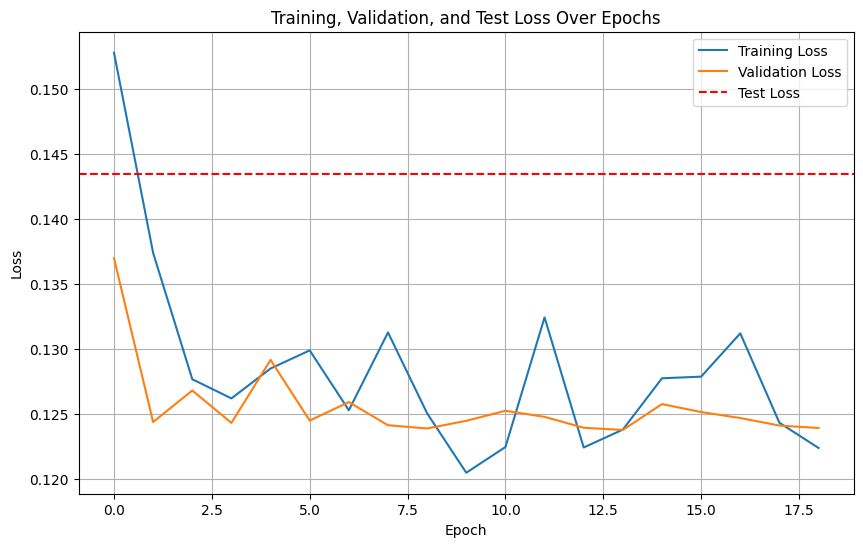

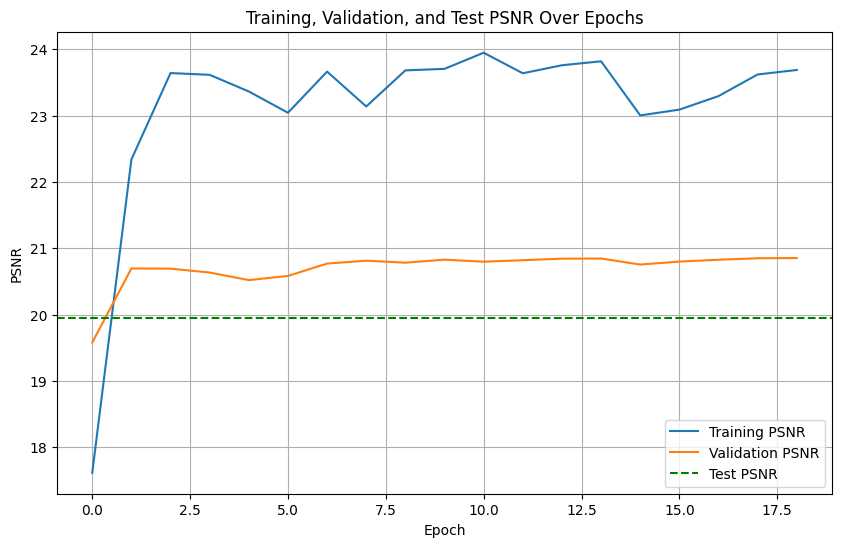

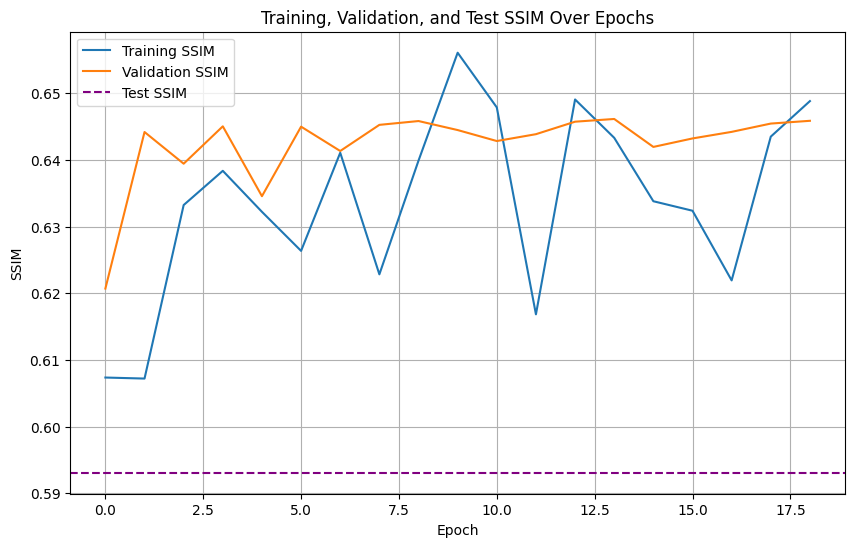

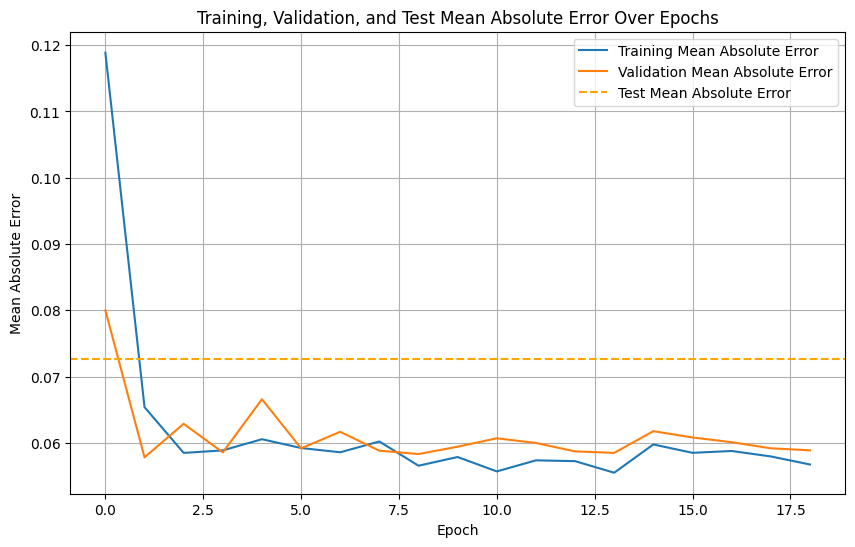

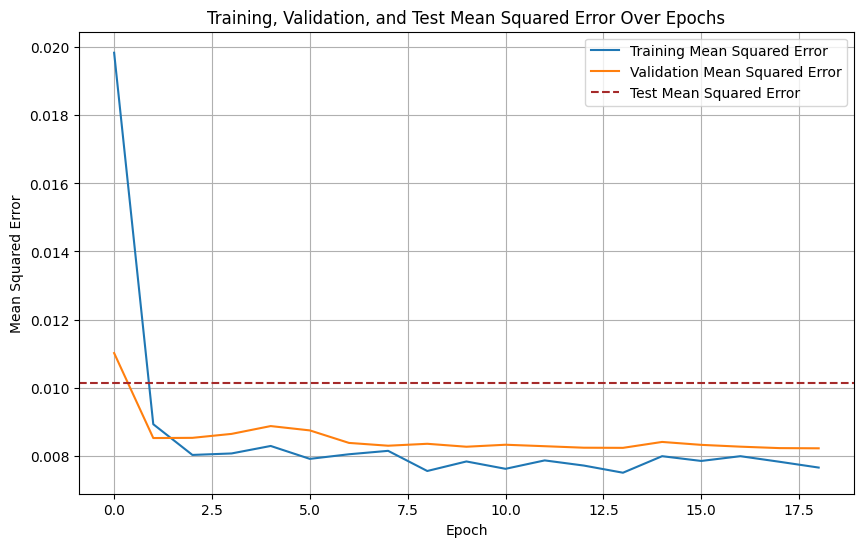

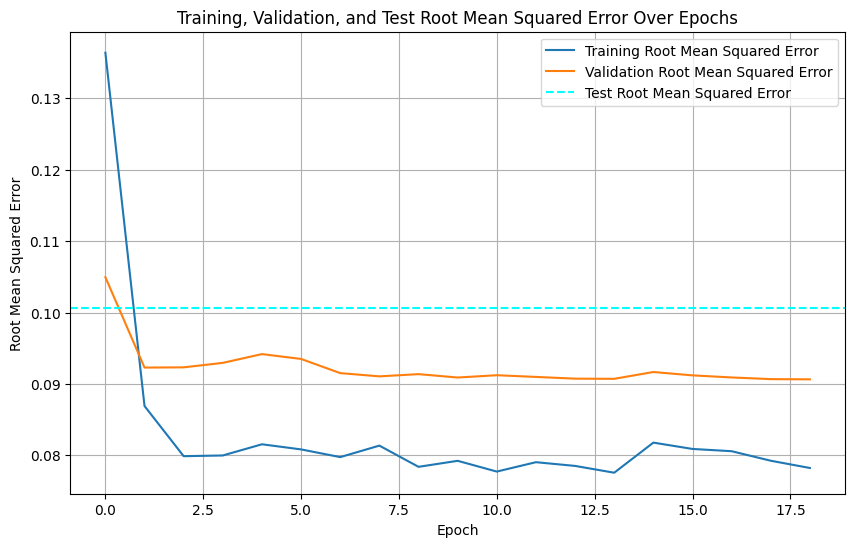

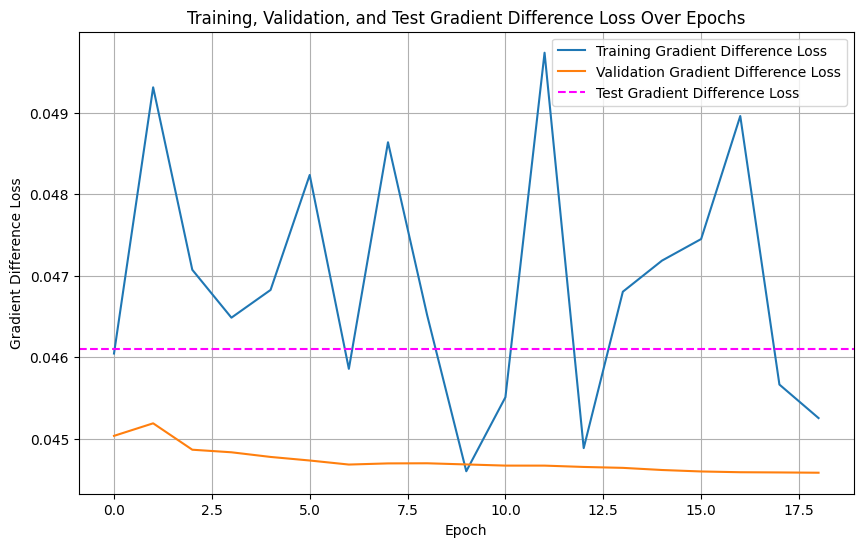

In [369]:
if 'hist' in globals() and hist:
    plot_metrics(hist)
else:
    logging.error("History (hist) dictionary not found or is empty. Cannot plot metrics.")